### Initial Imports and Data Splits

In [5]:
# import statements --> SOME OF THESE MAY NOT BE NEEDED
%matplotlib inline 
import numpy as np 

from matplotlib import pyplot as plt 
from matplotlib.cm import get_cmap
from matplotlib.ticker import StrMethodFormatter
from matplotlib.ticker import MultipleLocator
#from matplotlib.ticker import MaxNLocator
#import matplotlib.gridspec as gridspec
#import matplotlib.colors as mcolors
#import colorcet as cc
#from matplotlib.patches import Rectangle, FancyArrowPatch
#import matplotlib.ticker as ticker
#from mpl_toolkits.mplot3d import Axes3D
#from mpl_toolkits.axes_grid1 import make_axes_locatable
#import mpl_scatter_density
#from astropy.visualization import LogStretch
#from astropy.visualization.mpl_normalize import ImageNormalize

#import h5py

#from astropy.io import fits,ascii,votable
#from astropy import units as u 
#from astropy import constants as const
#from astropy import table
#from astropy.cosmology import Planck15,FlatLambdaCDM
#from astropy.table import Table

#from sklearn.cluster import KMeans
#from sklearn import mixture
#from itertools import combinations
#from sklearn.neighbors import KNeighborsRegressor
#from sklearn.utils import check_array
#from sklearn.neighbors._base import _get_weights
#imports for TWO-NN
#import scipy
from sklearn import neighbors
#from sklearn import preprocessing

#import scipy.integrate
#from scipy.integrate import quad
#import numba
#from sklearn.datasets import load_digits
import umap
from umap.umap_ import nearest_neighbors
import pandas as pd
#import plotly
import plotly.express as px

#imports for plotly graphing
#import plotly.graph_objects as go
#from plotly.subplots import make_subplots

import pickle

pd.set_option('display.max_columns', None)

#BRETT NOTEBOOK IMPORTS
from pathlib import Path

from importlib import reload
import utils
reload(utils)
from minisom import MiniSom

# imports from animation_simplified2 notebook
import seaborn as sns
sns.set(style='white', rc={'figure.figsize':(14, 12), 'animation.html': 'html5'})
import os
import copy

In [6]:
import umapz2

In [7]:
data = pd.read_parquet('COSMOS2020_processed_260724.parquet')
spec95 = pd.read_parquet('speczCL95_processed_260724.parquet')
#spec95 = spec95.drop(columns=['SOM-1', 'SOM-2', 'UMAP3D-1', 'UMAP3D-2', 'UMAP3D-3'])
#spec95 = spec95[spec95['specz']>0.0]
#spec95 = pd.merge(left=spec95[['ID', 'specz']], right=data, left_on='ID', right_on='ID')

In [8]:
splits = umapz2.data_split(photcat=data, speccat=spec95, valid_size=len(spec95), rs=41)

### uncertainty due to k-value optimization

In [9]:
valid=splits['valid'].copy()

In [10]:
reload(umapz2)

<module 'umapz2' from '/Users/finianashmead/Desktop/research/paper1/umapz2.py'>

In [11]:
# o for optimization, e for euclidean, m for manhattan
k_o_s = [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27]

k_o_mean_sets_e = {str(k_o): [0] for k_o in k_o_s}
k_o_mean_results_e = {str(k_o): [0] for k_o in k_o_s}
k_o_median_sets_e = {str(k_o): [0] for k_o in k_o_s}
k_o_median_results_e = {str(k_o): [0] for k_o in k_o_s}
k_o_mean_sets_m = {str(k_o): [0] for k_o in k_o_s}
k_o_mean_results_m = {str(k_o): [0] for k_o in k_o_s}
k_o_median_sets_m = {str(k_o): [0] for k_o in k_o_s}
k_o_median_results_m = {str(k_o): [0] for k_o in k_o_s}

k_o_mean_outliers_mean_e = []
k_o_mean_outliers_std_e = []
k_o_mean_nmads_mean_e = []
k_o_mean_nmads_std_e = []
k_o_mean_biases_mean_e = []
k_o_mean_biases_std_e = []
k_o_median_outliers_mean_e = []
k_o_median_outliers_std_e = []
k_o_median_nmads_mean_e = []
k_o_median_nmads_std_e = []
k_o_median_biases_mean_e = []
k_o_median_biases_std_e = []
k_o_mean_outliers_mean_m = []
k_o_mean_outliers_std_m = []
k_o_mean_nmads_mean_m = []
k_o_mean_nmads_std_m = []
k_o_mean_biases_mean_m = []
k_o_mean_biases_std_m = []
k_o_median_outliers_mean_m = []
k_o_median_outliers_std_m = []
k_o_median_nmads_mean_m = []
k_o_median_nmads_std_m = []
k_o_median_biases_mean_m = []
k_o_median_biases_std_m = []

for k_o in k_o_s:
    k_o_mean_results_e[str(k_o)], k_o_mean_sets_e[str(k_o)] = umapz2.crossvalidate_global(folds=5, data=valid, nn=k_o,
                                                                            map='', tv='lp_photoz', calc='mean',
                                                                            colors=True, p=2)
    k_o_median_results_e[str(k_o)], k_o_median_sets_e[str(k_o)] = umapz2.crossvalidate_global(folds=5, data=valid, nn=k_o,
                                                                            map='', tv='lp_photoz', calc='median',
                                                                            colors=True, p=2)
    k_o_mean_results_m[str(k_o)], k_o_mean_sets_m[str(k_o)] = umapz2.crossvalidate_global(folds=5, data=valid, nn=k_o,
                                                                            map='', tv='lp_photoz', calc='mean',
                                                                            colors=True, p=1)
    k_o_median_results_m[str(k_o)], k_o_median_sets_m[str(k_o)] = umapz2.crossvalidate_global(folds=5, data=valid, nn=k_o,
                                                                            map='', tv='lp_photoz', calc='median',
                                                                            colors=True, p=1)
    
    k_o_mean_outliers_mean_e.append(k_o_mean_results_e[str(k_o)]['outliers_mean'])
    k_o_mean_outliers_std_e.append(k_o_mean_results_e[str(k_o)]['outliers_range'])
    k_o_mean_nmads_mean_e.append(k_o_mean_results_e[str(k_o)]['nmads_mean'])
    k_o_mean_nmads_std_e.append(k_o_mean_results_e[str(k_o)]['nmads_range'])
    k_o_mean_biases_mean_e.append(k_o_mean_results_e[str(k_o)]['biases_mean'])
    k_o_mean_biases_std_e.append(k_o_mean_results_e[str(k_o)]['biases_range'])

    k_o_median_outliers_mean_e.append(k_o_median_results_e[str(k_o)]['outliers_mean'])
    k_o_median_outliers_std_e.append(k_o_median_results_e[str(k_o)]['outliers_range'])
    k_o_median_nmads_mean_e.append(k_o_median_results_e[str(k_o)]['nmads_mean'])
    k_o_median_nmads_std_e.append(k_o_median_results_e[str(k_o)]['nmads_range'])
    k_o_median_biases_mean_e.append(k_o_median_results_e[str(k_o)]['biases_mean'])
    k_o_median_biases_std_e.append(k_o_median_results_e[str(k_o)]['biases_range'])

    k_o_mean_outliers_mean_m.append(k_o_mean_results_m[str(k_o)]['outliers_mean'])
    k_o_mean_outliers_std_m.append(k_o_mean_results_m[str(k_o)]['outliers_range'])
    k_o_mean_nmads_mean_m.append(k_o_mean_results_m[str(k_o)]['nmads_mean'])
    k_o_mean_nmads_std_m.append(k_o_mean_results_m[str(k_o)]['nmads_range'])
    k_o_mean_biases_mean_m.append(k_o_mean_results_m[str(k_o)]['biases_mean'])
    k_o_mean_biases_std_m.append(k_o_mean_results_m[str(k_o)]['biases_range'])

    k_o_median_outliers_mean_m.append(k_o_median_results_m[str(k_o)]['outliers_mean'])
    k_o_median_outliers_std_m.append(k_o_median_results_m[str(k_o)]['outliers_range'])
    k_o_median_nmads_mean_m.append(k_o_median_results_m[str(k_o)]['nmads_mean'])
    k_o_median_nmads_std_m.append(k_o_median_results_m[str(k_o)]['nmads_range'])
    k_o_median_biases_mean_m.append(k_o_median_results_m[str(k_o)]['biases_mean'])
    k_o_median_biases_std_m.append(k_o_median_results_m[str(k_o)]['biases_range'])



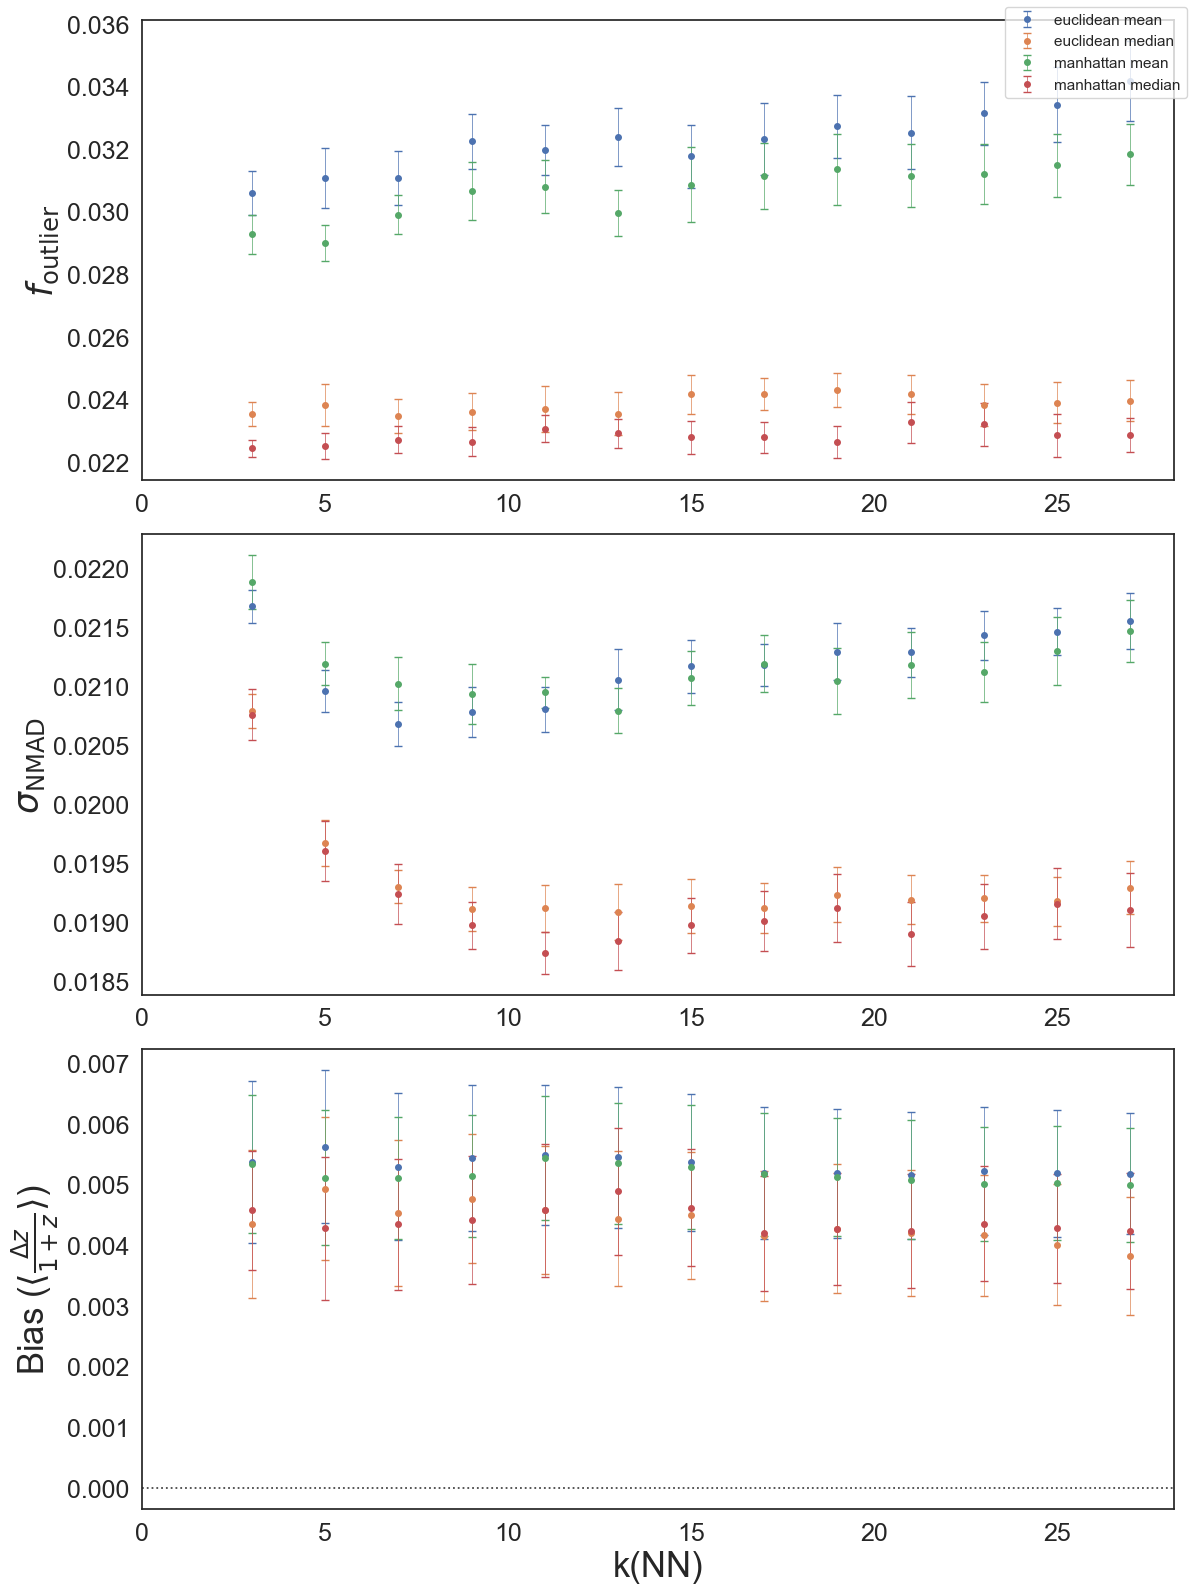

In [12]:
if 1:
    filename=None
    fig, axs = plt.subplots(3, 1, figsize=(12,16))
    c0, c1, c2, c3 = 'C0', 'C1', 'C2', 'C3'

    
    ylo = None
    # OUTLIERS
    axs[0].errorbar(k_o_s, k_o_mean_outliers_mean_e, yerr=(0.5*np.asarray(k_o_mean_outliers_std_e)), fmt='o', capsize=3,
            lw=0.5, ms=4, alpha=1., c=c0, label='euclidean mean')
    axs[0].errorbar(k_o_s, k_o_median_outliers_mean_e, yerr=(0.5*np.asarray(k_o_median_outliers_std_e)), fmt='o', capsize=3,
            lw=0.5, ms=4, alpha=1., c=c1, label='euclidean median')
    axs[0].errorbar(k_o_s, k_o_mean_outliers_mean_m, yerr=(0.5*np.asarray(k_o_mean_outliers_std_m)), fmt='o', capsize=3,
            lw=0.5, ms=4, alpha=1., c=c2, label='manhattan mean')
    axs[0].errorbar(k_o_s, k_o_median_outliers_mean_m, yerr=(0.5*np.asarray(k_o_median_outliers_std_m)), fmt='o', capsize=3,
            lw=0.5, ms=4, alpha=1., c=c3, label='manhattan median')

    
    axs[0].tick_params(axis='y', labelsize=18)
    axs[0].tick_params(axis='x', labelsize=18)
    axs[0].set_xlim(0,None)
    axs[0].set_ylabel(r'$f_\mathrm{outlier}$', fontsize=25)

    # NMADS
    axs[1].errorbar(k_o_s, k_o_mean_nmads_mean_e, yerr=(0.5*np.asarray(k_o_mean_nmads_std_e)), fmt='o', capsize=3,
            lw=0.5, ms=4, alpha=1., c=c0)
    axs[1].errorbar(k_o_s, k_o_median_nmads_mean_e, yerr=(0.5*np.asarray(k_o_median_nmads_std_e)), fmt='o', capsize=3,
            lw=0.5, ms=4, alpha=1., c=c1)
    axs[1].errorbar(k_o_s, k_o_mean_nmads_mean_m, yerr=(0.5*np.asarray(k_o_mean_nmads_std_m)), fmt='o', capsize=3,
            lw=0.5, ms=4, alpha=1., c=c2)
    axs[1].errorbar(k_o_s, k_o_median_nmads_mean_m, yerr=(0.5*np.asarray(k_o_median_nmads_std_m)), fmt='o', capsize=3,
            lw=0.5, ms=4, alpha=1., c=c3)

    axs[1].tick_params(axis='y', labelsize=18)
    axs[1].tick_params(axis='x', labelsize=18)
    axs[1].set_xlim(0,None)
    axs[1].set_ylabel(r'$\sigma_\mathrm{NMAD}$', fontsize=25)

    # BIASES
    axs[2].errorbar(k_o_s, k_o_mean_biases_mean_e, yerr=(0.5*np.asarray(k_o_mean_biases_std_e)), fmt='o', capsize=3,
            lw=0.5, ms=4, alpha=1., c=c0)
    axs[2].errorbar(k_o_s, k_o_median_biases_mean_e, yerr=(0.5*np.asarray(k_o_median_biases_std_e)), fmt='o', capsize=3,
            lw=0.5, ms=4, alpha=1., c=c1)
    axs[2].errorbar(k_o_s, k_o_mean_biases_mean_m, yerr=(0.5*np.asarray(k_o_mean_biases_std_m)), fmt='o', capsize=3,
            lw=0.5, ms=4, alpha=1., c=c2)
    axs[2].errorbar(k_o_s, k_o_median_biases_mean_m, yerr=(0.5*np.asarray(k_o_median_biases_std_m)), fmt='o', capsize=3,
            lw=0.5, ms=4, alpha=1., c=c3)

    axs[2].axhline(y = 0.0, color = 'k', linestyle =':', lw=1.3, alpha=0.8)
    axs[2].set_xlim(0,None)
    axs[2].tick_params(axis='y', labelsize=18)
    axs[2].tick_params(axis='x', labelsize=18)
    axs[2].set_xlabel('k(NN)', fontsize=25)
    axs[2].set_ylabel('Bias ('+r'$\langle \frac{\Delta z}{1+z} \rangle$'+')', fontsize=25)
    fig.subplots_adjust(top=0.95)
    fig.tight_layout()
    fig.legend()
    if filename!=None:
        fig.savefig(filename, bbox_inches='tight')

Based on these results, the Manhattan metric with median-based interpolation is the best approach. Looking particularly the NMAD results, we choose k=11 as the ideal value, with 9 and 13 corresponding to the +/-15% values.

In [ ]:
ks = [9, 11, 13]
k_sets = {str(k): [0] for k in ks}
k_b_results = {str(k): [0] for k in ks}

k_b_outliers_mean = []
k_b_nmads_mean = []
k_b_biases_mean = []

for k in ks:
    k_b_results[str(k)], k_sets[str(k)] = umapz2.crossvalidate_binned(folds=5, data=valid, nn=k, map='', tv='lp_photoz', colors=True, p=1)
    k_b_outliers_mean.append(k_b_results[str(k)]['outliers_mean'])
    k_b_nmads_mean.append(k_b_results[str(k)]['nmads_mean'])
    k_b_biases_mean.append(k_b_results[str(k)]['biases_mean'])

unc_k_outliers = (np.asarray(k_b_outliers_mean).max(axis=0) - np.asarray(k_b_outliers_mean).min(axis=0))/2
unc_k_nmads = (np.asarray(k_b_nmads_mean).max(axis=0) - np.asarray(k_b_nmads_mean).min(axis=0))/2
unc_k_biases = (np.asarray(k_b_biases_mean).max(axis=0) - np.asarray(k_b_biases_mean).min(axis=0))/2

Here I'll take the half the range of means for each metric (f_out, nmad, bias) in each redshift bin as the uncertainty due to k-value choice in that bin. We could alternatively incorporate the ranges into this calculation, but I will leave it this way for now --> FOLLOW UP

In [16]:
k_binned_results = {
'bin_centers':k_b_results['11']['bin_centers'],
'outliers_mean':k_b_results['11']['outliers_mean'],
'nmads_mean':k_b_results['11']['nmads_mean'],
'biases_mean':k_b_results['11']['biases_mean'],
'unc_k_outliers':unc_k_outliers,
'unc_k_nmads':unc_k_nmads,
'unc_k_biases':unc_k_biases
}

### uncertainty due to finite test set

To quantify the uncertainty due to the finite test set, we take 10-25 bootstrap samples of the test set (spec-z-trained case) and perform the main redshift-binned interpolation test with fixed k. The standard deviation of the performance metrics in each bin will be taken as the uncertainty due to finite test size.

We need to perform the interpolation once each for the spec-z- and LePHARE-trained cases, and then will resample from the results to generate the boostrapped statistics.

In [19]:
test_lp = splits['test_lp'].copy()
test_s = splits['test_spec'].copy()
train_lp = splits['train_lp'].copy()
train_s = splits['train_spec'].copy()

In [20]:
# spec-z-trained
test_s['TEST_Z'] = umapz2.interpolator_colors(df1=train_s, df2=test_s, coords=['u-g', 'g-r', 'r-i', 'i-z', 
                                    'z-y', 'y-J', 'J-H'], nn=11, calc='median', z_true='specz', p=1).copy()['TEST_Z']
outliers_s = umapz2.f_outlier(i_vals=test_s['TEST_Z'], t_vals=test_s['lp_photoz'], missing=0, threshold=0.15)
nmads_s = umapz2.calc_nmad(i_vals=test_s['TEST_Z'], t_vals=test_s['lp_photoz'])
biases_s = umapz2.calc_bias(i_vals=test_s['TEST_Z'], t_vals=test_s['lp_photoz'])

# LePHARE-trained
test_lp['TEST_Z'] = umapz2.interpolator_colors(df1=train_lp, df2=test_lp, coords=['u-g', 'g-r', 'r-i', 'i-z', 
                                    'z-y', 'y-J', 'J-H'], nn=11, calc='median', z_true='lp_photoz', p=1).copy()['TEST_Z']
outliers_lp = umapz2.f_outlier(i_vals=test_lp['TEST_Z'], t_vals=test_lp['lp_photoz'], missing=0, threshold=0.15)
nmads_lp = umapz2.calc_nmad(i_vals=test_lp['TEST_Z'], t_vals=test_lp['lp_photoz'])
biases_lp = umapz2.calc_bias(i_vals=test_lp['TEST_Z'], t_vals=test_lp['lp_photoz'])

In [21]:
binned_s = umapz2.binned_stats_old(fullcat=test_s, testcat=test_s, iv='TEST_Z', tv='lp_photoz',
                                bin_var='lp_photoz', bin_min=0.0, bin_max=3.0, bin_size=0.2)
binned_lp = umapz2.binned_stats_old(fullcat=test_lp, testcat=test_lp, iv='TEST_Z', tv='lp_photoz',
                                bin_var='lp_photoz', bin_min=0.0, bin_max=3.0, bin_size=0.2)

In [22]:
#with open("binned_results_colors_manhattan_s_260513.pkl", "wb") as f:
#    pickle.dump(binned_s, f)

#with open("binned_results_colors_manhattan_lp_260513.pkl", "wb") as f:
#    pickle.dump(binned_lp, f)

In [ ]:
n_boots=25
outliers_boots = []
nmads_boots = []
stdevs_boots = []
biases_boots = []
testcats_boots = []
outliers_boots_lp = []
nmads_boots_lp = []
stdevs_boots_lp = []
biases_boots_lp = []
testcats_boots_lp = []

for i in range(1, n_boots+1):
    boot_i = test_s.sample(n=len(test_s), replace=True, random_state=i)
    testcats_boots.append(boot_i.copy())
    outliers_boots.append(umapz2.f_outlier(i_vals=boot_i['TEST_Z'], t_vals=boot_i['lp_photoz'], 
                                           missing=0, threshold=0.15))
    nmads_boots.append(umapz2.calc_nmad(i_vals=boot_i['TEST_Z'], t_vals=boot_i['lp_photoz']))
    stdevs_boots.append(umapz2.calc_stdev(i_vals=boot_i['TEST_Z'], t_vals=boot_i['lp_photoz']))
    biases_boots.append(umapz2.calc_bias(i_vals=boot_i['TEST_Z'], t_vals=boot_i['lp_photoz']))

    boot_i_lp = test_lp.sample(n=len(test_lp), replace=True, random_state=i)
    testcats_boots_lp.append(boot_i_lp.copy())
    outliers_boots_lp.append(umapz2.f_outlier(i_vals=boot_i_lp['TEST_Z'], t_vals=boot_i_lp['lp_photoz'], 
                                           missing=0, threshold=0.15))
    nmads_boots_lp.append(umapz2.calc_nmad(i_vals=boot_i_lp['TEST_Z'], t_vals=boot_i_lp['lp_photoz']))
    stdevs_boots_lp.append(umapz2.calc_stdev(i_vals=boot_i_lp['TEST_Z'], t_vals=boot_i_lp['lp_photoz']))
    biases_boots_lp.append(umapz2.calc_bias(i_vals=boot_i_lp['TEST_Z'], t_vals=boot_i_lp['lp_photoz']))

In [24]:
# convert to arrays: shape = (n_realizations, n_bins)
outliers_boots = np.asarray(outliers_boots)
nmads_boots = np.asarray(nmads_boots)
stdevs_boots = np.asarray(stdevs_boots)
biases_boots = np.asarray(biases_boots)

outliers_boots_lp = np.asarray(outliers_boots_lp)
nmads_boots_lp = np.asarray(nmads_boots_lp)
stdevs_boots_lp = np.asarray(stdevs_boots_lp)
biases_boots_lp = np.asarray(biases_boots_lp)

boots_results = {
    "outliers_mean": outliers_boots.mean(axis=0),
    "outliers_std": outliers_boots.std(axis=0),

    "nmads_mean": nmads_boots.mean(axis=0),
    "nmads_std": nmads_boots.std(axis=0),

    "stdevs_mean": stdevs_boots.mean(axis=0),
    "stdevs_std": stdevs_boots.std(axis=0),

    "biases_mean": biases_boots.mean(axis=0),
    "biases_std": biases_boots.std(axis=0),

    "outliers_mean_lp": outliers_boots_lp.mean(axis=0),
    "outliers_std_lp": outliers_boots_lp.std(axis=0),

    "nmads_mean_lp": nmads_boots_lp.mean(axis=0),
    "nmads_std_lp": nmads_boots_lp.std(axis=0),

    "stdevs_mean_lp": stdevs_boots_lp.mean(axis=0),
    "stdevs_std_lp": stdevs_boots_lp.std(axis=0),

    "biases_mean_lp": biases_boots_lp.mean(axis=0),
    "biases_std_lp": biases_boots_lp.std(axis=0)
}

In [25]:
metrics = ['outliers', 'nmads', 'stdevs', 'biases']
for metric in metrics:
    print(metric+' mean:', np.round(boots_results[metric+'_mean'], 6))
    print(metric+' stdev:', np.round(boots_results[metric+'_std'], 6))

outliers mean: 0.025685
outliers stdev: 0.000527
nmads mean: 0.022271
nmads stdev: 0.000108
stdevs mean: 0.134524
stdevs stdev: 0.003194
biases mean: 0.003744
biases stdev: 0.000379


In [26]:
boots_binned_results = umapz2.binned_stats_ensemble(fullcats=testcats_boots, testcats=testcats_boots, iv='TEST_Z', tv='lp_photoz', bin_var='lp_photoz',
                            bin_min=0.0, bin_max=3.0, bin_size=0.2)

boots_binned_results_lp = umapz2.binned_stats_ensemble(fullcats=testcats_boots_lp, testcats=testcats_boots_lp, iv='TEST_Z', tv='lp_photoz', bin_var='lp_photoz',
                            bin_min=0.0, bin_max=3.0, bin_size=0.2)

In [27]:
len(splits['train_spec'][splits['train_spec']['specz']>1.5])

989

In [28]:
print(len(valid[valid['lp_photoz']>1.5]))
print(len(valid))

2370
14477


### Calculate total uncertainties (added in quadrature) and write out the results to use the error bars in performance figures.

In [32]:
# LePHARE-trained case
metric='outliers'
unc1_lp, unc2_lp = [boots_binned_results_lp[metric+'_std'], k_binned_results['unc_k_'+metric]]
colors_outlier_uncs_lp = np.sqrt(unc1_lp**2 + unc2_lp**2)
metric='nmads'
unc1_lp, unc2_lp = [boots_binned_results_lp[metric+'_std'], k_binned_results['unc_k_'+metric]]
colors_nmad_uncs_lp = np.sqrt(unc1_lp**2 + unc2_lp**2)
metric='biases'
unc1_lp, unc2_lp = [boots_binned_results_lp[metric+'_std'], k_binned_results['unc_k_'+metric]]
colors_bias_uncs_lp = np.sqrt(unc1_lp**2 + unc2_lp**2)

# spec-z-trained case
metric='outliers'
unc1, unc2 = [boots_binned_results[metric+'_std'], k_binned_results['unc_k_'+metric]]
colors_outlier_uncs = np.sqrt(unc1**2 + unc2**2)
metric='nmads'
unc1, unc2 = [boots_binned_results[metric+'_std'], k_binned_results['unc_k_'+metric]]
colors_nmad_uncs = np.sqrt(unc1**2 + unc2**2)
metric='biases'
unc1, unc2, = [boots_binned_results[metric+'_std'], k_binned_results['unc_k_'+metric]]
colors_bias_uncs = np.sqrt(unc1**2 + unc2**2)

In [33]:
colors_errs = {'outliers':colors_outlier_uncs, 'nmads':colors_nmad_uncs, 'biases':colors_bias_uncs,
            'outliers_lp':colors_outlier_uncs_lp, 'nmads_lp':colors_nmad_uncs_lp, 'biases_lp':colors_bias_uncs_lp}

In [34]:
#with open("colors_kNN_z_manhattan_errs_260513.pkl", "wb") as f: #comment out when not ready to use, for safety against overwriting :)
#    pickle.dump(colors_errs, f)

### Global Performance Metric Uncertainties

This section will compute the uncertainties on the full-sample performance statistics. The same approach will be used, taking the range of means divided by 2 for the uncertainties associated with our embedding/interpolator choices (n_neighbors, k), using 5-fold crossvalidation tests on the validation sample, and taking the standard deviation of the performance metrics obtained over 25 trials for the uncertainties associated with embedding random seed (25 seeds, spec-z train/test sets) and the finite test set (25 bootstraps of the (spec-z) test sample for one random seed run).

In [24]:
# valid contains the cell coordinates for the validation dataset for various embedding choice combinations, 
# all using the same random seed (42)
# this data is used to calculate the +/-15% uncertainties associated with choice of these
# parameters

In [35]:
ks = [9, 11, 13]
n_boots = 25

In [36]:
# UNCERTAINTY DUE TO K-VALUE CHOICE
# adding g for unique variables for global quantities
kg_sets = {str(k): [0] for k in ks}
kg_results = {str(k): [0] for k in ks}

kg_outliers_mean = []
kg_nmads_mean = []
kg_biases_mean = []

for k in ks:
    kg_results[str(k)], kg_sets[str(k)] = umapz2.crossvalidate_global(folds=5, data=valid, nn=k, map='', tv='lp_photoz', colors=True, p=1)
    kg_outliers_mean.append(kg_results[str(k)]['outliers_mean'])
    kg_nmads_mean.append(kg_results[str(k)]['nmads_mean'])
    kg_biases_mean.append(kg_results[str(k)]['biases_mean'])

unc_kg_outliers = (np.asarray(kg_outliers_mean).max(axis=0) - np.asarray(kg_outliers_mean).min(axis=0))/2
unc_kg_nmads = (np.asarray(kg_nmads_mean).max(axis=0) - np.asarray(kg_nmads_mean).min(axis=0))/2
unc_kg_biases = (np.asarray(kg_biases_mean).max(axis=0) - np.asarray(kg_biases_mean).min(axis=0))/2

In [37]:
metric='outliers'
colors_outlier_unc = np.sqrt(unc_kg_outliers**2 + (boots_results[metric+'_std'])**2)
colors_outlier_unc_lp = np.sqrt(unc_kg_outliers**2 + (boots_results[metric+'_std_lp'])**2)

metric='nmads'
colors_nmad_unc = np.sqrt(unc_kg_nmads**2 + (boots_results[metric+'_std'])**2)
colors_nmad_unc_lp = np.sqrt(unc_kg_nmads**2 + (boots_results[metric+'_std_lp'])**2)

metric='biases'
colors_bias_unc = np.sqrt(unc_kg_biases**2 + (boots_results[metric+'_std'])**2)
colors_bias_unc_lp = np.sqrt(unc_kg_biases**2 + (boots_results[metric+'_std_lp'])**2)

In [38]:
unc_kg_outliers

0.00020723003082090408

In [39]:
unc_kg_nmads

0.00011751228258518806

In [40]:
unc_kg_biases

0.0002390438835319147

### Global Stats w/ Uncertainties:

In [41]:
print('colors-kNN-z (spec-z-trained) f_outlier: '+str(np.round(outliers_s,4))+' +/- '+str(np.round(colors_outlier_unc, 4)))
print('colors-kNN-z (spec-z-trained) NMAD: '+str(np.round(nmads_s,4))+' +/- '+str(np.round(colors_nmad_unc, 4)))
print('colors-kNN-z (spec-z-trained) bias: '+str(np.round(biases_s,4))+' +/- '+str(np.round(colors_bias_unc, 4)))

colors-kNN-z (spec-z-trained) f_outlier: 0.0257 +/- 0.0006
colors-kNN-z (spec-z-trained) NMAD: 0.0223 +/- 0.0002
colors-kNN-z (spec-z-trained) bias: 0.0037 +/- 0.0004


In [42]:
print('colors-kNN-z (LePHARE-trained) f_outlier: '+str(np.round(outliers_lp,4))+' +/- '+str(np.round(colors_outlier_unc_lp, 4)))
print('colors-kNN-z (LePHARE-trained) NMAD: '+str(np.round(nmads_lp,4))+' +/- '+str(np.round(colors_nmad_unc_lp, 4)))
print('colors-kNN-z (LePHARE-trained) bias: '+str(np.round(biases_lp,4))+' +/- '+str(np.round(colors_bias_unc_lp, 4)))

colors-kNN-z (LePHARE-trained) f_outlier: 0.0198 +/- 0.0005
colors-kNN-z (LePHARE-trained) NMAD: 0.0182 +/- 0.0002
colors-kNN-z (LePHARE-trained) bias: 0.0039 +/- 0.0004


In [60]:
colors_global = {
'specz_trained':{
    'f_outlier':{
        'f_outlier':outliers_s,
        'unc':colors_outlier_unc,
        'unc_k':unc_kg_outliers,
        'unc_boots':boots_results['outliers_std']
    },
    'nmad':{
        'nmad':nmads_s,
        'unc':colors_nmad_unc,
        'unc_k':unc_kg_nmads,
        'unc_boots':boots_results['nmads_std']    
    },
    'bias':{
        'bias':biases_s,
        'unc':colors_bias_unc,
        'unc_k':unc_kg_biases,
        'unc_boots':boots_results['biases_std']
    },

},
'LePHARE_trained':{
    'f_outlier':{
        'f_outlier':outliers_lp,
        'unc':colors_outlier_unc_lp,
        'unc_k':unc_kg_outliers,
        'unc_boots':boots_results['outliers_std_lp']
    },
    'nmad':{
        'nmad':nmads_lp,
        'unc':colors_nmad_unc_lp,
        'unc_k':unc_kg_nmads,
        'unc_boots':boots_results['nmads_std_lp']    
    },
    'bias':{
        'bias':biases_lp,
        'unc':colors_bias_unc_lp,
        'unc_k':unc_kg_biases,
        'unc_boots':boots_results['biases_std_lp']
    },

}
}

In [61]:
#with open("colors_global_260513.pkl", "wb") as f:
#    pickle.dump(colors_global, f)

In [55]:
colors_binned = {
'specz_trained':{
    'f_outlier':{
        'f_outlier':np.asarray(binned_s['outliers']),
        #'unc':colors_outlier_uncs,
        'unc_k':k_binned_results['unc_k_outliers'],
        'unc_boots':boots_binned_results['outliers_std']
    },
    'nmad':{
        'nmad':np.asarray(binned_s['nmads']),
        'unc_k':k_binned_results['unc_k_nmads'],
        'unc_boots':boots_binned_results['nmads_std']
    },
    'bias':{
        'bias':np.asarray(binned_s['biases']),
        'unc_k':k_binned_results['unc_k_biases'],
        'unc_boots':boots_binned_results['biases_std']
    },
    'bin_centers':binned_s['bin_centers']

},
'LePHARE_trained':{
    'f_outlier':{
        'f_outlier':np.asarray(binned_lp['outliers']),
        'unc_k':k_binned_results['unc_k_outliers'],
        'unc_boots':boots_binned_results_lp['outliers_std']
    },
    'nmad':{
        'nmad':np.asarray(binned_lp['nmads']),
        'unc_k':k_binned_results['unc_k_nmads'],
        'unc_boots':boots_binned_results_lp['nmads_std']
    },
    'bias':{
        'bias':np.asarray(binned_lp['biases']),
        'unc_k':k_binned_results['unc_k_biases'],
        'unc_boots':boots_binned_results_lp['biases_std']
    },
    'bin_centers':binned_lp['bin_centers']

}
}

In [56]:
#with open("colors_binned_260513.pkl", "wb") as f: #comment out when not ready to use, for safety against overwriting :)
#    pickle.dump(colors_binned, f)